#**HR Attrition Prediction**

#**Problem Statement**

Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.
In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:

- Age
 -   Salary
 -  Job Role
 -  Job Satisfaction
 -  Work Experience
 -  Overtime
 -  Work-Life Balance
 -  Department

Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting employee attrition.

#**Objectives**

The objective of this task is to:

-  Understand and explore the HR dataset
- Perform data preprocessing (missing values, duplicates, outliers)
- Conduct Exploratory Data Analysis (EDA)
- Apply encoding and feature scaling
- Train multiple classification algorithms
- Evaluate models using classification metrics
- Perform cross-validation and hyperparameter tuning
- Select the best-performing model





#**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Load dataset**

In [ ]:
data=pd.read_csv('Employee-Attrition.csv')
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


#**Explore data veriebles**

The Employee Attrition dataset contains information about employees in an organization. It includes demographic details, job-related information, performance metrics, and satisfaction levels. The dataset is used to analyze factors influencing employee turnover.


**Age-** Employee’s age

**Gender–** Male/Female

**MaritalStatus –** Single/Married/Divorced

**Education –** Education level

**EducationField –** Field of study

**JobRole –** Employee’s role in the company

**Department –** Department name

**JobLevel –** Level of job position

**YearsAtCompany –** Total years worked in the company

**YearsInCurrentRole –** Years in current role

**YearsWithCurrManager –** Years with current manager

**BusinessTravel –** Frequency of business travel

**OverTime –** Whether the employee works overtime (Yes/No)

**MonthlyIncome –** Monthly salary

**DailyRate –** Daily wage

**MonthlyRate –** Monthly rate

**PercentSalaryHike –** Salary increase percentage

**StockOptionLevel –** Level of stock options

**JobSatisfaction –** Satisfaction level

**RelationshipSatisfaction –** Relationship with colleagues

**WorkLifeBalance –** Work-life balance rating

**PerformanceRating –** Employee performance rating

**JobInvolvement –** Level of job involvement

**TotalWorkingYears –** Total work experience

**TrainingTimesLastYear –** Training attended last year



#**Perform a basic checks**

In [ ]:
#find no of rows and columns
data.shape

(1470, 35)

In [ ]:
#fetch 5 rows
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
#fetch last 5 rows
data.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [ ]:
data.loc[:,'OverTime']

,OverTime
0,Yes
1,No
2,Yes
3,Yes
4,No
...,...
1465,No
1466,No
1467,Yes
1468,No


In [ ]:
#find data types
data.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
#check data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
#check number of columns
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
#find a num_data
num_data=data.select_dtypes(include=('int64','float64'))
num_data

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
#find cata-data
cat_data=data.select_dtypes(include=('object'))
cat_data

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [ ]:
#check satastical report
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
#find unique values in cat_data
for x in cat_data:
  print(f"{x}---->{data[x].unique()}")
  print("")

Attrition---->['Yes' 'No']

BusinessTravel---->['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department---->['Sales' 'Research & Development' 'Human Resources']

EducationField---->['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender---->['Female' 'Male']

JobRole---->['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus---->['Single' 'Married' 'Divorced']

Over18---->['Y']

OverTime---->['Yes' 'No']



In [ ]:
#find value_counts in cat_data
for x in cat_data:
  print(f"{x}---->{data[x].value_counts()}")
  print("")

Attrition---->Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel---->BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department---->Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField---->EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender---->Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole---->JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus---->Mar

#**Handle missing values and Duplicate values**


#Checck Duplicate values

In [ ]:
#Find duplicate values
data.duplicated().sum()

np.int64(0)

There in no **Duplicate values** in the **Employee Attrition** data

#**Check missing values**

In [ ]:
#Find the missing values
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


There is no **missing values** in the **Employee Attrition**

#**Analyse data using visualization**

#**count the **Attrition****

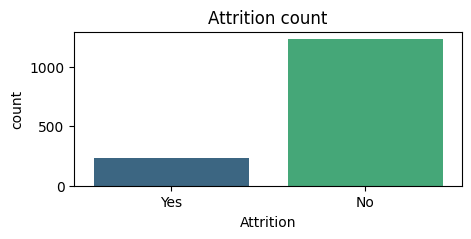

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data, x="Attrition", hue='Attrition',  palette='viridis')
plt.title("Attrition count")
plt.show()

**Insights**

-  The count plot shows that the majority of employees did not leave the company, indicating strong employee retention.

-  A smaller number of employees experienced attrition, which suggests that employee turnover exists but is relatively low.

-  The dataset shows an imbalance between the two categories, with more employees staying than leaving.

-  This indicates that further analysis of factors such as job satisfaction, salary, and overtime is necessary to understand the reasons behind employee attrition.

#**count BusinessTravel of employee Attrition**

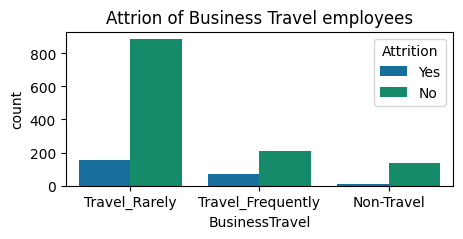

In [ ]:

plt.figure(figsize=(5,2))
sns.countplot(data, x='BusinessTravel' , hue='Attrition',  palette='colorblind6')
plt.title("Attrion of Business Travel employees")

plt.show()

#**Insights**

#**Count Department wise Attrition**

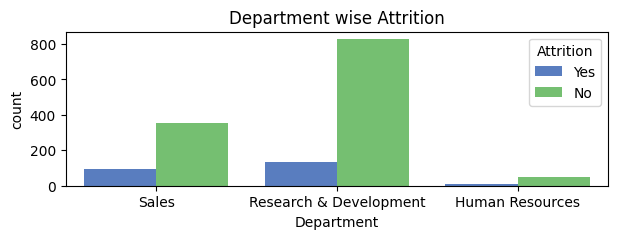

In [ ]:
plt.figure(figsize=(7,2))
sns.countplot(data, x='Department' , hue='Attrition',  palette='muted6')
plt.title("Department wise Attrition")
plt.show()

#**Insights**

-  The count plot shows the distribution of employees based on their business travel frequency and attrition status.

-  Employees who travel rarely appear to have the highest count in the dataset compared to other travel categories.

-  A noticeable number of employees who travel frequently tend to show higher attrition compared to those who do not travel.

-  This suggests that frequent business travel may contribute to employee turnover due to factors such as work pressure, travel fatigue, or work–life balance issues.

#**Count Attrition at Education field**

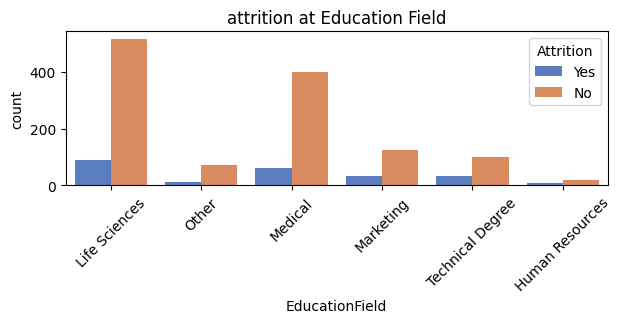

In [ ]:
plt.figure(figsize=(7,2))
sns.countplot(data, x='EducationField' , hue='Attrition',  palette='muted')
plt.title("attrition at Education Field")
plt.xticks(rotation=45)
plt.show()

#**Insights**

-  The count plot shows the distribution of employees across different education fields along with their attrition status.

-  Employees from the Life Sciences and Medical education fields have the highest number of employees in the dataset.

-  Attrition is also more noticeable in these fields because they contain a larger portion of the workforce.

-  Other fields such as Human Resources, Technical Degree, and Marketing have comparatively fewer employees and lower attrition counts.

#**Count gender wise Attrition**

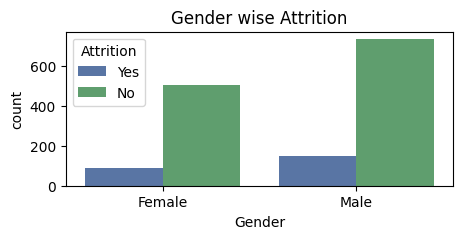

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data, x='Gender' , hue='Attrition',  palette='deep6')
plt.title("Gender wise Attrition")
plt.show()

#**Insights**

-  The count plot shows the distribution of employees by gender along with their attrition status.

-  The dataset contains a higher number of male employees compared to female employees.

-  Attrition is slightly higher among male employees, mainly because they represent a larger portion of the workforce.

-  Female employees show comparatively lower attrition counts in the organization.

**Is there age matters for employee attrition**

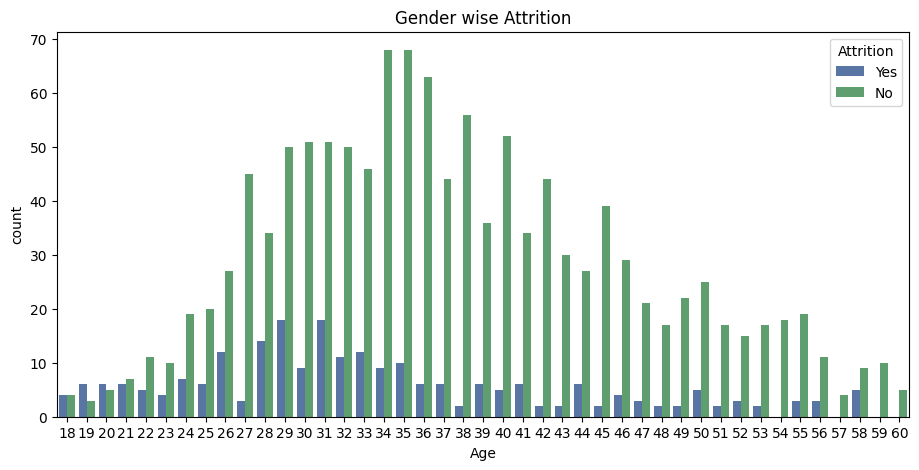

In [ ]:
plt.figure(figsize=(11,5))
sns.countplot(data, x='Age' , hue='Attrition',  palette='deep6')
plt.title("Gender wise Attrition")
plt.show()

**Insights**

- few peoples in the age between 25  to 35 are ready for attrition
- employees are not ready to leave the job in the age of 40
- few peoples are ready to quite a job in the age of 20
- more peoples are continued their job in the age of 35
- overall age is not that much impacted for employee attrition

#**count Attrition at JobRole**

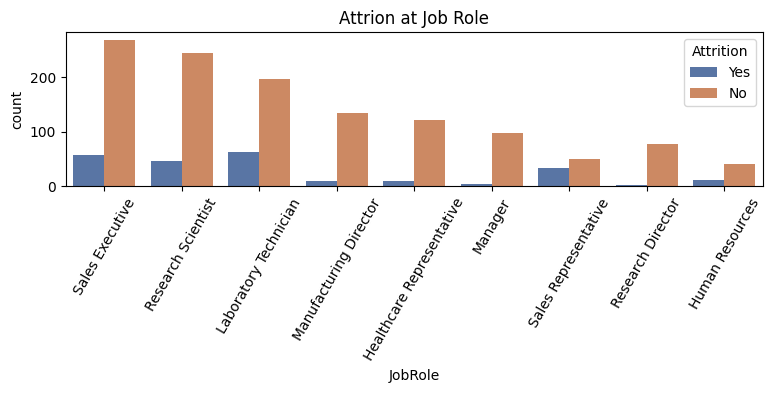

In [ ]:
plt.figure(figsize=(9,2))
sns.countplot(data, x='JobRole' , hue='Attrition',  palette='deep')
plt.title("Attrion at Job Role")
plt.xticks(rotation=60)
plt.show()

#**Insights**

-  The count plot shows the distribution of employees across different job roles along with their attrition status.

-  Sales Executive, Research Scientist, and Laboratory Technician roles have the highest number of employees in the dataset.

-  Attrition appears to be higher in Sales Executive and Laboratory Technician roles compared to other job roles.

-  Some job roles such as Manager and Research Director have fewer employees and relatively lower attrition levels.

#**Distribution of dailyrate Attrition**

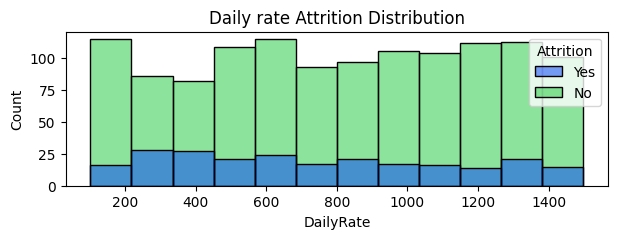

In [ ]:
plt.figure(figsize=(7,2))
sns.histplot(data, x='DailyRate' , hue='Attrition',  palette='bright6')
plt.title("Daily rate Attrition Distribution")
plt.show()

#**Insights**

-  The histogram shows the distribution of employees’ DailyRate along with their attrition status.

-  Employees are distributed across a wide range of daily salary rates in the organization.

-  Attrition occurs across almost all daily rate ranges, indicating that employees leave at different salary levels.

-  This suggests that daily pay alone may not be the main factor influencing employee attrition, and other factors such as job satisfaction, workload, or work environment may also play a role.

#**Distribution of Distane from Home**

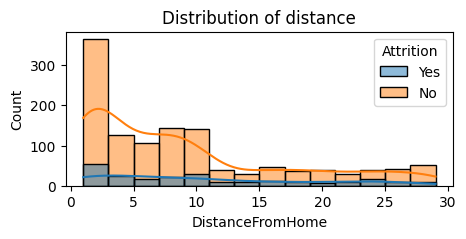

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data, x='DistanceFromHome',hue='Attrition', kde=True)
plt.title("Distribution of distance")
plt.show()

#**Insights**

-  The histogram shows the distribution of employees’ DistanceFromHome along with their attrition status.

-  Most employees live closer to the workplace, as higher counts are observed at lower distance values.

-  Employees who live farther from the workplace appear to have slightly higher attrition compared to those living nearby.

-  This suggests that long commuting distance may contribute to employee turnover, possibly due to travel time and work–life balance issues.

#**Distribution of Employee Number according to Attrition**

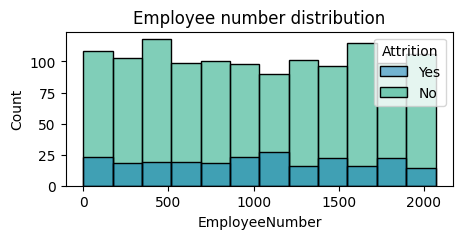

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='EmployeeNumber', hue='Attrition',  palette='colorblind6')
plt.title("Employee number distribution")
plt.show()

#**Insights**

-  The histogram shows the distribution of EmployeeNumber along with their attrition status.

-  The employee numbers are evenly distributed across the dataset, indicating that they are used mainly as a unique identifier for employees.

-  There is no clear relationship between EmployeeNumber and attrition, as employees who stayed and left are spread throughout the range.

-  This suggests that EmployeeNumber is only an identification variable and does not influence employee attrition.

#**Distribution of Hourly Rate**

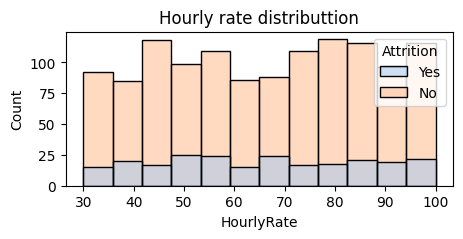

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data, x='HourlyRate' , hue='Attrition',  palette='pastel')
plt.title("Hourly rate distributtion")
plt.show()

#**Insights**

-  The histogram shows the distribution of employees’ HourlyRate along with their attrition status.

-  Employees are spread across different hourly pay ranges in the organization.

-  Attrition occurs at various hourly rate levels, indicating that employees leave the company regardless of their hourly pay.

- This suggests that hourly rate may not be a major factor affecting employee attrition, and other factors such as job satisfaction, workload, or work environment may influence employee turnover.

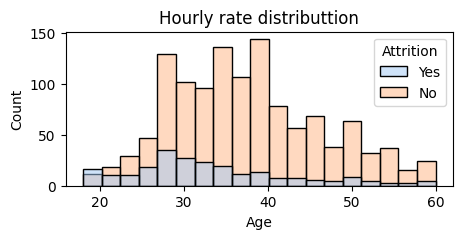

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data, x='Age' , hue='Attrition',  palette='pastel')
plt.title("Hourly rate distributtion")
plt.show()

#**Percentage of Martial Status**

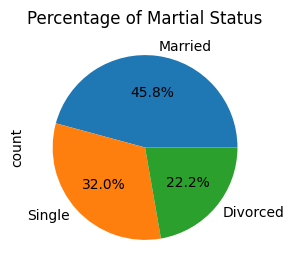

In [ ]:
plt.figure(figsize=(9,3))
data.loc[:,'MaritalStatus'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Percentage of Martial Status")
plt.show()

#**Insights**

-  The pie chart shows the percentage distribution of employees based on their marital status.

-  A larger portion of employees in the dataset are married, indicating that most employees have a family background.

-  Single employees also represent a significant portion of the workforce.

-  The divorced category has the smallest percentage compared to the other marital status groups.

#**Percentage of Job Role**

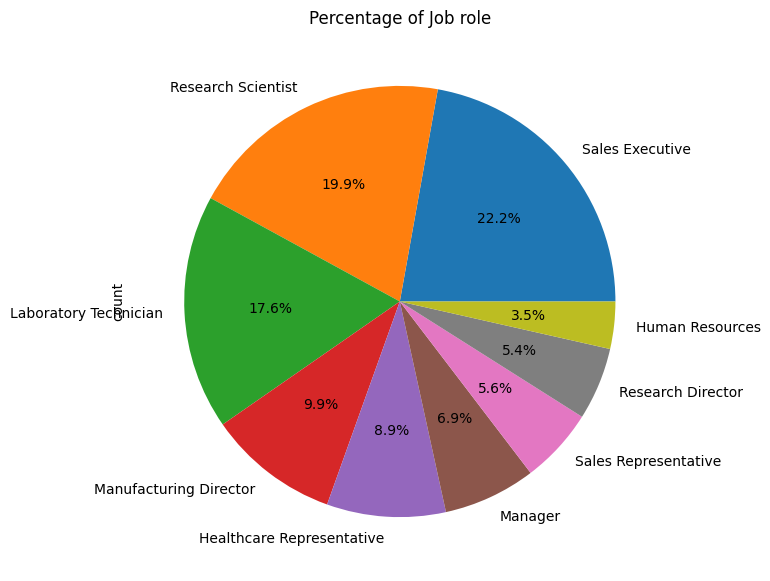

In [ ]:
plt.figure(figsize=(15,7))
data.loc[:,'JobRole'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Percentage of Job role")
plt.show()

#**Insights**

-  The pie chart shows the percentage distribution of employees across different job roles in the organization.

-  Sales Executive, Research Scientist, and Laboratory Technician make up the largest portions of employees in the dataset.

-  Some job roles such as Manager and Research Director represent a smaller percentage of the workforce.

-  This indicates that the organization has more employees in operational and technical roles compared to managerial roles.

#**Percentage of Educational fields**

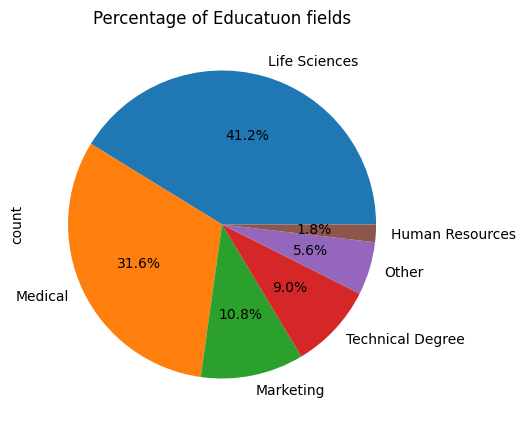

In [ ]:
plt.figure(figsize=(11,5))
data.loc[:,'EducationField'].value_counts().plot.pie(autopct='%1.1f%%' )
plt.title("Percentage of Educatuon fields")
plt.show()

#**Insights**

-  The pie chart shows the percentage distribution of employees across different education fields.

-  Life Sciences has the highest percentage of employees in the dataset.

-  Medical and Marketing fields also contribute a noticeable portion of the workforce.

-  Other fields such as Human Resources and Technical Degree represent a smaller percentage of employees.

#**Attrition Proportion**

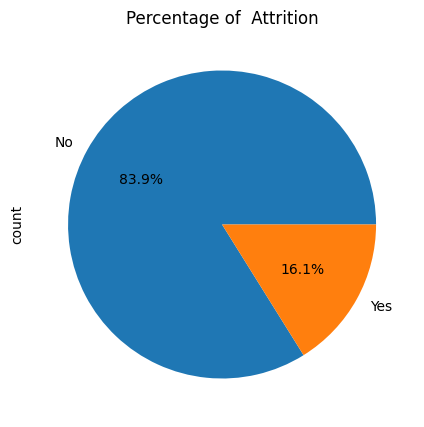

In [ ]:
plt.figure(figsize=(11,5))
data.loc[:,'Attrition'].value_counts().plot.pie(autopct='%1.1f%%' )
plt.title("Percentage of  Attrition")
plt.show()

#**Insights**

- Only 16.1% of employees are willing to quiet a job
- More than 80% employees are not ready to leave a job
- it clearly shows only few amount of peoples are resign a job due to some reasons
- more number of employees are happy with their job

#**Relationship between age and daily rate at attrition**

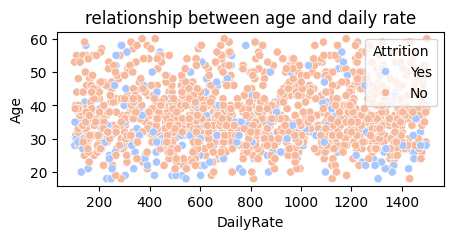

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(data, y='Age',x='DailyRate', hue='Attrition',palette='coolwarm')
plt.title("relationship between age and daily rate")
plt.show()

#**Insights**

-  The scatter plot shows the relationship between Age and DailyRate, along with employee attrition status.

-  Employees of different age groups receive a wide range of daily salary rates in the organization.

-  Attrition is observed across multiple age groups and salary ranges, indicating that employees leave at different stages of their careers.

-  This suggests that age and daily rate alone do not strongly determine employee attrition, and other factors may influence employees’ decisions to leave.


#**Relationship between Year at Company and Daily rate of Attrion**

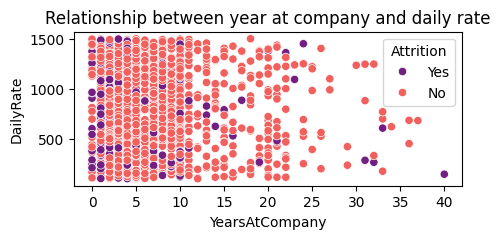

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(data, x='YearsAtCompany',y='DailyRate', hue='Attrition', palette='magma')
plt.title("Relationship between year at company and daily rate")
plt.show()

#**Insights**
-  The scatter plot shows the relationship between YearsAtCompany and DailyRate, along with employee attrition status.

-  Employees with different daily rates are distributed across various years of experience in the company.

-  Attrition occurs at different levels of years at the company, but it appears slightly higher among employees with fewer years of experience.

-  This suggests that employees who have recently joined the company may be more likely to leave compared to long-term employees.


#**Daily rate gender wise Attrition**

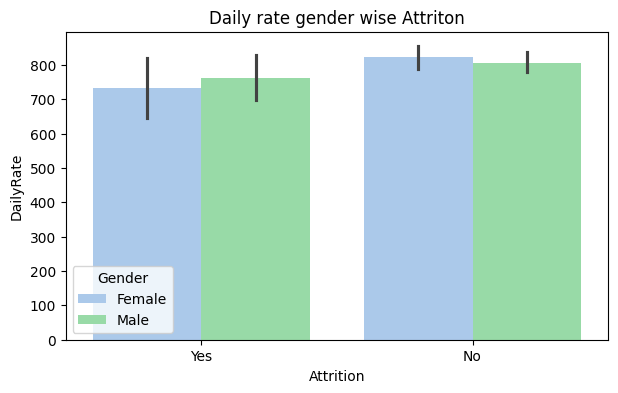

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data, x='Attrition',y='DailyRate', hue='Gender', palette='pastel6')
plt.title("Daily rate gender wise Attriton")
plt.show()

#**Insights**

-  The bar plot shows the average DailyRate of employees based on Attrition status and Gender.

-  Both male and female employees have similar average daily rates in the organization.

-  Attrition is observed among both genders, indicating that employees leave regardless of gender.

-  This suggests that gender and daily rate do not show a strong difference in employee attrition.

#**Department wise employee year at company**

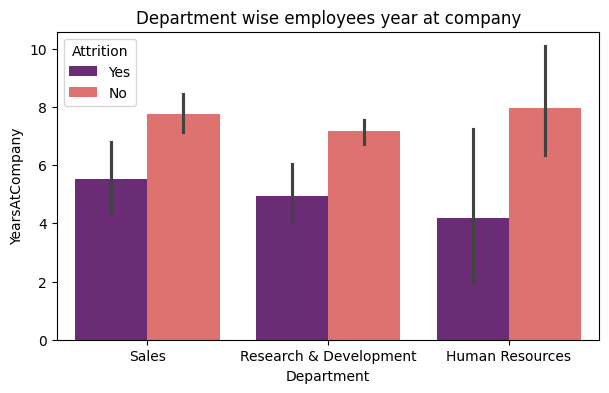

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data, x='Department', y='YearsAtCompany',hue='Attrition', palette='magma' )
plt.title("Department wise employees year at company")
plt.show()

#**Insights**

-  The bar plot shows the average YearsAtCompany for employees across different departments along with their attrition status.

-  Employees in different departments have varying levels of experience in the company.

-  Attrition is observed in all departments, indicating that employees leave from multiple organizational areas.

-  This suggests that employee retention may vary by department, and further analysis may help identify which departments experience higher turnover.

#**attrition at total working years with respect to education field**

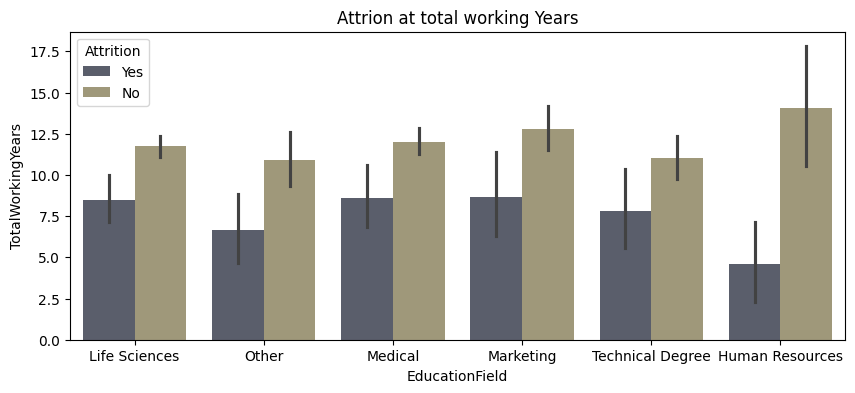

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(data, x='EducationField', y='TotalWorkingYears',hue='Attrition', palette='cividis' )
plt.title("Attrion at total working Years")
plt.show()

#**Insights**

-  The bar plot shows the average TotalWorkingYears of employees across different education fields along with their attrition status.

-  Employees from different education fields have varying levels of total work experience.

-  Attrition is observed among employees with both lower and higher total working years across education fields.

-  This indicates that total working experience alone may not be the only factor influencing employee attrition.

#**Attrition at Job role with respect to education**

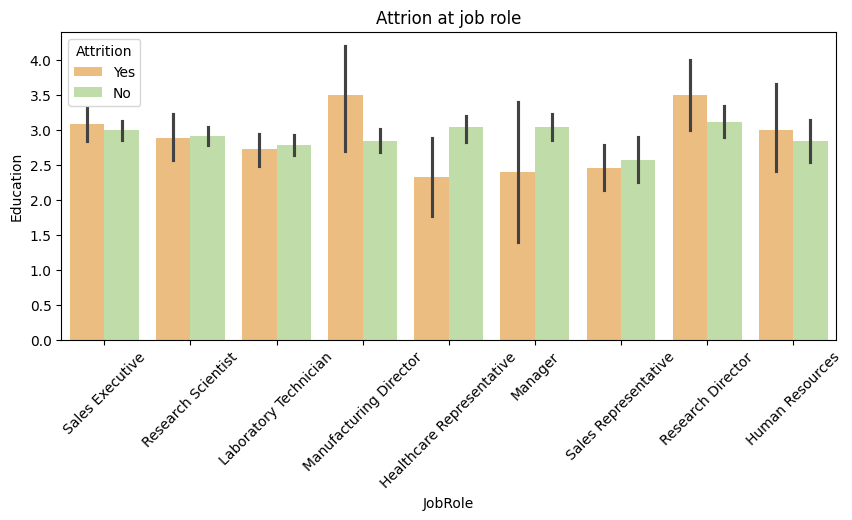

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(data, x='JobRole', y='Education',hue='Attrition', palette='Spectral' )
plt.xticks(rotation=45)
plt.title("Attrion at job role")
plt.show()

#**Insights**

-  The bar plot shows the average education level of employees across different job roles along with their attrition status.

-  Different job roles have varying education levels among employees in the organization.

-  Attrition is observed across multiple job roles and education levels, indicating that employees leave from different roles regardless of education level.

-  This suggests that education level alone may not strongly influence employee attrition across job roles.

#**Gender wise Employees business Travel**

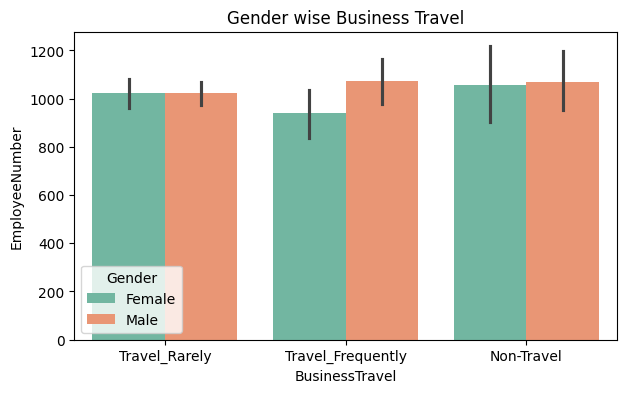

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data, x='BusinessTravel',y='EmployeeNumber',hue='Gender', palette='Set2' )
plt.title("Gender wise Business Travel")
plt.show()

#**Insights**

-  The bar plot shows the distribution of employees based on BusinessTravel frequency and Gender.

-  Most employees fall under the Travel_Rarely category, indicating that frequent travel is not common for many employees.

-  Both male and female employees are present across all travel categories.

-  This suggests that business travel opportunities are distributed among both genders, with no strong gender dominance in travel frequency.


#**extrame values at StockOptionLevel**

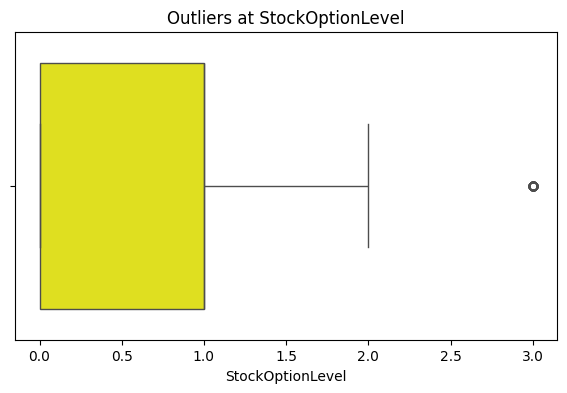

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data, x='StockOptionLevel', color='yellow')
plt.title("Outliers at StockOptionLevel")
plt.show()





**Insights**

-  The box plot shows the distribution of StockOptionLevel among employees.

-  Most employees have lower stock option levels, indicating limited stock benefits for many employees.

-  The data appears to have very few or no significant outliers in stock option levels.

-  This suggests that stock option levels are fairly consistent across employees in the organization.

#**extrame values at TotalWorkingYears**

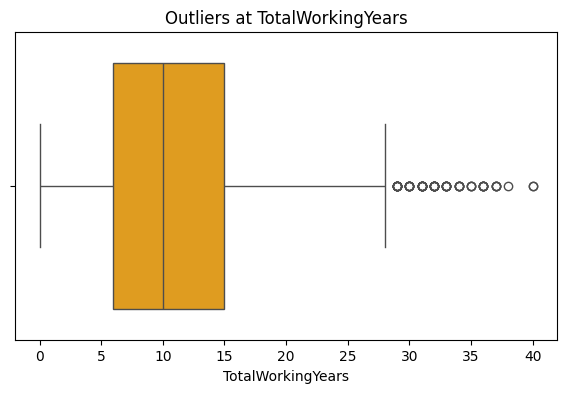

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data, x='TotalWorkingYears', color='orange')
plt.title("Outliers at TotalWorkingYears")
plt.show()

#**Insights**

-  The box plot shows the distribution of TotalWorkingYears among employees in the dataset.

-  Most employees have moderate total working experience, indicating a workforce with mid-level experience.

-  The plot shows some outliers at higher working years, representing employees with very long work experience.

-  This suggests that while most employees have average experience levels, a few employees have significantly higher total working years.

#**extrame values at TrainingTimesLastYear**

> Add blockquote



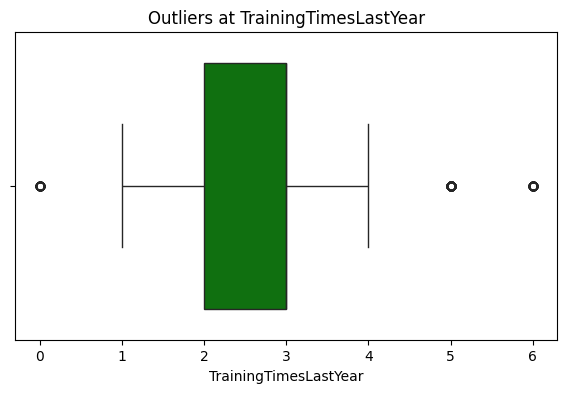

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data, x='TrainingTimesLastYear', color='green')
plt.title("Outliers at TrainingTimesLastYear")
plt.show()




#**Insights**

-  The box plot shows the distribution of TrainingTimesLastYear among employees.

-  Most employees received a moderate number of training sessions during the last year.

-  The plot may show a few outliers, indicating that some employees attended significantly more training sessions than others.

-  This suggests that training opportunities vary among employees, with some receiving more training than the majority.

#**extrame values at Year at company**

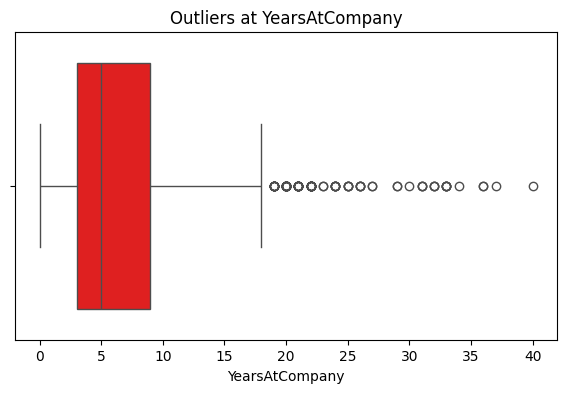

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data, x='YearsAtCompany', color='red')
plt.title("Outliers at YearsAtCompany")
plt.show()

#**Insights**

-  The box plot shows the distribution of YearsAtCompany among employees.

-  Most employees have spent a moderate number of years in the company.

-  The plot shows some outliers at higher years, representing employees who have stayed in the company for a very long time.

-  This indicates that while many employees have average tenure, a few employees have very long-term association with the organization.

#**extrame values at YearsInCurrentRole**

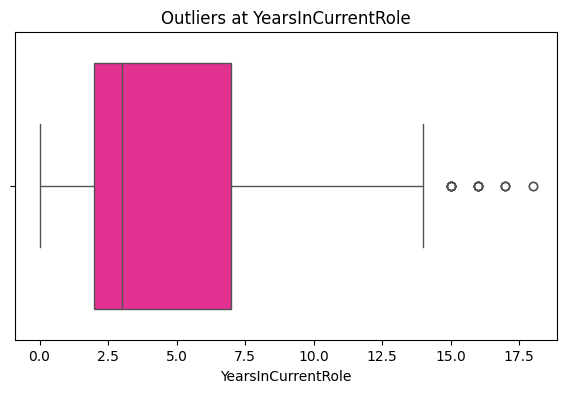

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data, x='YearsInCurrentRole', color='deeppink')
plt.title("Outliers at YearsInCurrentRole")
plt.show()

#**Insights**

-  The box plot shows the distribution of YearsInCurrentRole among employees.

-  Most employees have spent a moderate number of years in their current role.

-  The plot may show a few outliers at higher values, representing employees who have stayed in the same role for many years.

-  This indicates that while many employees change roles within a reasonable time, some remain in the same position for a longer period.


#**extrame values at Year since last promotion**

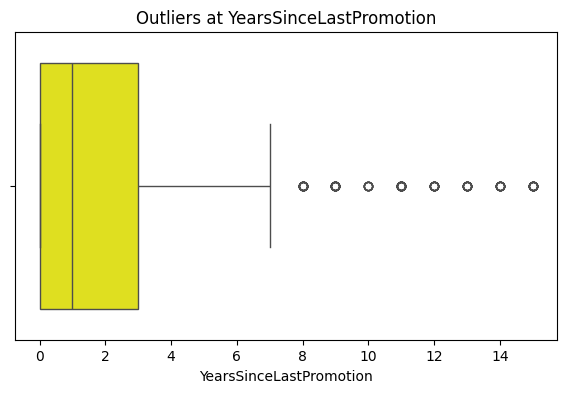

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data, x='YearsSinceLastPromotion', color='yellow')
plt.title("Outliers at YearsSinceLastPromotion")
plt.show()

#**Insights**

-  The box plot shows the distribution of YearsSinceLastPromotion among employees.

-  Most employees have received promotions within a moderate time period.

-  The plot shows some outliers at higher values, indicating that a few employees have not been promoted for many years.

-  This suggests that promotion opportunities may vary among employees, with some waiting longer for promotions.

#**extrame values at Year with Currmanager**

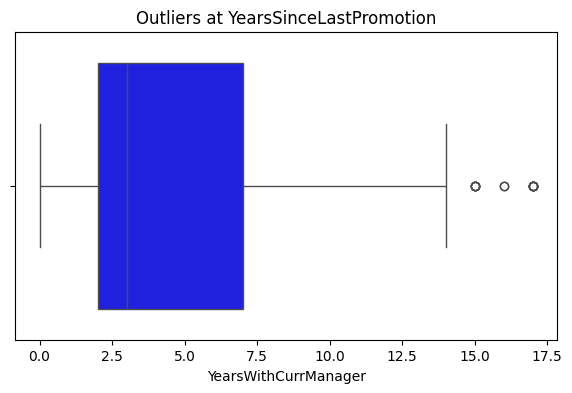

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data, x='YearsWithCurrManager', color='blue')
plt.title("Outliers at YearsSinceLastPromotion")
plt.show()

#**Insights**

-  The box plot shows the distribution of YearsWithCurrManager among employees.

-  Most employees have worked with their current manager for a moderate number of years.

-  The plot may show a few outliers at higher values, representing employees who have worked with the same manager for a long time.

-  This suggests that while many employees experience managerial changes over time, some remain under the same manager for many years.

#**correlation with all numerical data**

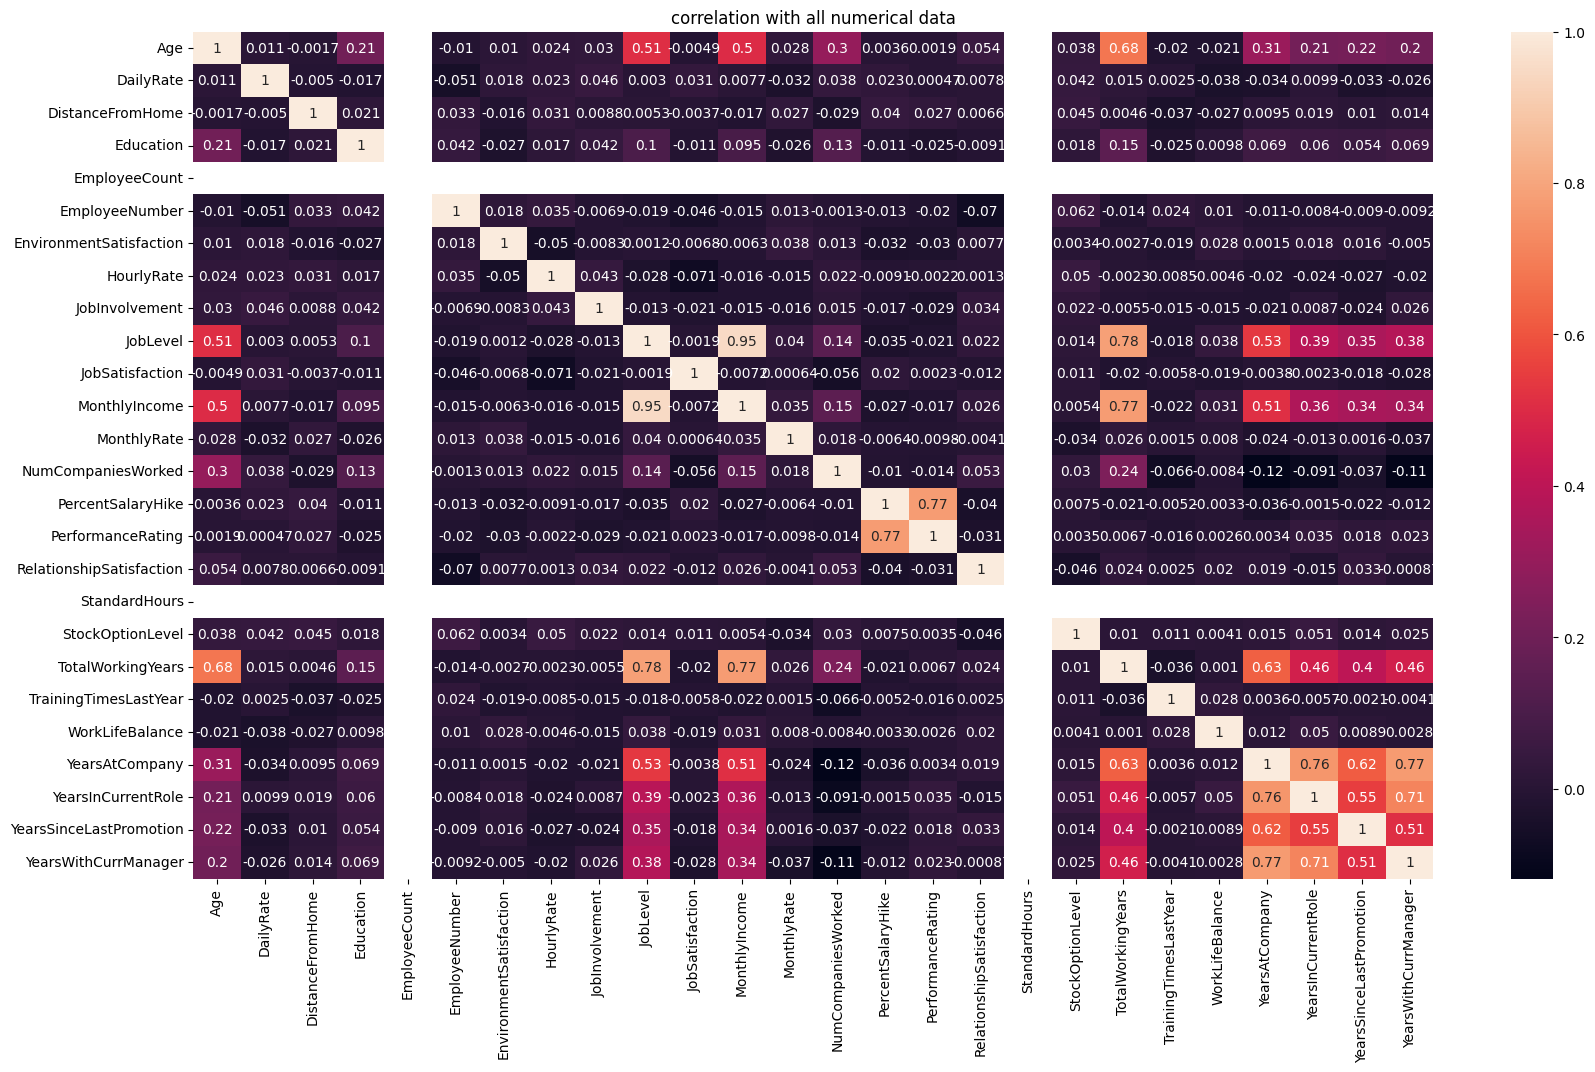

In [ ]:
plt.figure(figsize=(20,11))
sns.heatmap(num_data.corr(), annot=True)
plt.title("correlation with all numerical data")
plt.show()

#**Insights**


-  There are some numerical features that are strongly correlated with each other, which could affect model performance if not handled carefully.

-  A few features contain outliers that may distort the analysis and might need treatment, such as capping or transformation.

-  The distributions of certain columns are skewed, indicating that the data is not evenly spread and may require normalization or scaling.

-  Missing values or inconsistencies in some columns were observed, which need to be addressed to ensure accurate analysis.

#**Pairplot graph of all numerical data**

In [ ]:
plt.figure(figsize=(10,6))
sns.pairplot(data, hue='Attrition')
plt.title("correlation of all numerical data")
plt.show()

#**Handle Outliers**

#Check outliers in numerical columns

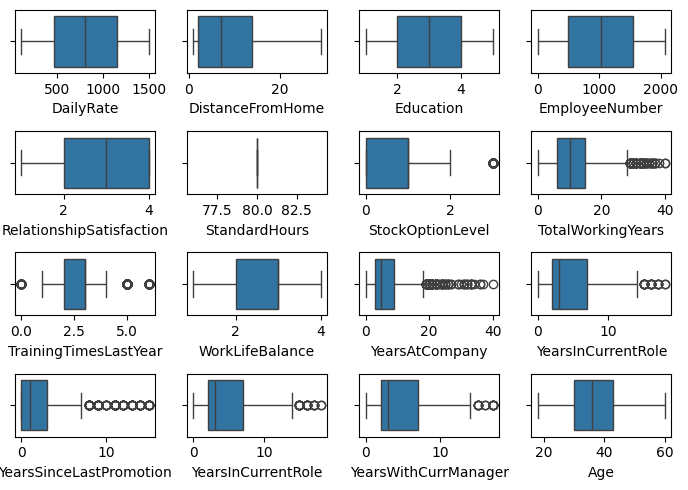

In [ ]:
fig,ax=plt.subplots(4,4,figsize=(7,5))
sns.boxplot(data,x='DailyRate',ax=ax[0,0])
sns.boxplot(data,x='DistanceFromHome',ax=ax[0,1])
sns.boxplot(data,x='Education',ax=ax[0,2])
sns.boxplot(data,x='EmployeeNumber',ax=ax[0,3])
sns.boxplot(data,x='RelationshipSatisfaction',ax=ax[1,0])
sns.boxplot(data,x='StandardHours',ax=ax[1,1])
sns.boxplot(data,x='StockOptionLevel',ax=ax[1,2])
sns.boxplot(data,x='TotalWorkingYears',ax=ax[1,3])
sns.boxplot(data,x='TrainingTimesLastYear',ax=ax[2,0])
sns.boxplot(data,x='WorkLifeBalance',ax=ax[2,1])
sns.boxplot(data,x='YearsAtCompany',ax=ax[2,2])
sns.boxplot(data,x='YearsInCurrentRole',ax=ax[2,3])
sns.boxplot(data,x='YearsSinceLastPromotion',ax=ax[3,0])
sns.boxplot(data,x='YearsInCurrentRole',ax=ax[3,1])
sns.boxplot(data,x='YearsWithCurrManager',ax=ax[3,2])
sns.boxplot(data,x='Age',ax=ax[3,3])

plt.tight_layout()


**Outliers are present in

**
-  'TotalWorkingYears',
- 'TrainingTimeLastYear',
- 'Yearatcompany',
- 'Yearsincurrentrole',
- 'yearsincelastpromotion',
- 'yearswithcurrentmanager',
- 'stockoptonlevel'**

**We have to check distribution to handle outliers**

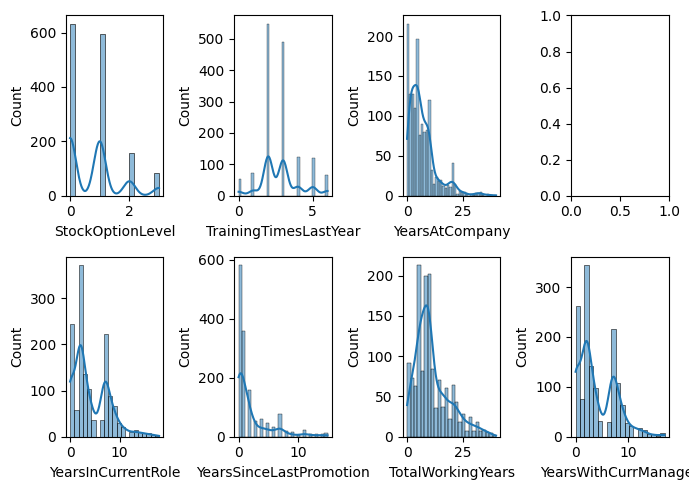

In [ ]:
#Check distribution
fig,ax=plt.subplots(2,4,figsize=(7,5))
sns.histplot(data,x='StockOptionLevel',kde=True,ax=ax[0,0])
sns.histplot(data,x='TrainingTimesLastYear',kde=True,ax=ax[0,1])
sns.histplot(data,x='YearsAtCompany',kde=True,ax=ax[0,2])
sns.histplot(data,x='YearsInCurrentRole',kde=True,ax=ax[1,0])
sns.histplot(data,x='YearsSinceLastPromotion',kde=True,ax=ax[1,1])
sns.histplot(data,x='TotalWorkingYears',kde=True,ax=ax[1,2])
sns.histplot(data,x='YearsWithCurrManager',kde=True,ax=ax[1,3])
plt.tight_layout()

In [ ]:
#Check distribution wheather its skewed or normal
A=['StockOptionLevel','TrainingTimesLastYear','YearsInCurrentRole','YearsSinceLastPromotion','TotalWorkingYears','YearsWithCurrManager',"YearsAtCompany"]
for x in A:
  print(x, data[x].skew())

StockOptionLevel 0.9689803167738937
TrainingTimesLastYear 0.5531241710537028
YearsInCurrentRole 0.9173631562908262
YearsSinceLastPromotion 1.9842899833524859
TotalWorkingYears 1.1171718528128527
YearsWithCurrManager 0.8334509919918475
YearsAtCompany 1.7645294543422085


**It clearly shows distribution of all numerical columns will be skewed. so we go through a IQR method to handle outliers**

**StockOptionLevel**

In [ ]:
Q1=data.loc[:,'StockOptionLevel'].quantile(0.25)
Q3=data.loc[:,'StockOptionLevel'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR



In [ ]:
#filter the values which are less than lower limit
data[data.loc[:,'StockOptionLevel']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
#filter the values which are more than upper limot
data[data.loc[:,'StockOptionLevel']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
64,36,No,Travel_Rarely,1223,Research & Development,8,3,Technical Degree,1,83,...,2,80,3,17,2,3,17,14,12,8
65,55,No,Travel_Rarely,836,Research & Development,8,3,Medical,1,84,...,3,80,3,21,2,3,5,0,0,2
83,38,No,Non-Travel,573,Research & Development,6,3,Medical,1,107,...,4,80,3,17,3,3,13,11,1,9
88,30,No,Travel_Rarely,288,Research & Development,2,3,Life Sciences,1,117,...,1,80,3,11,3,3,11,10,10,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1402,31,No,Travel_Rarely,1276,Research & Development,2,1,Medical,1,1974,...,3,80,3,1,4,3,1,0,0,0
1415,33,No,Non-Travel,1313,Research & Development,1,2,Medical,1,1994,...,3,80,3,1,2,2,1,1,0,0
1440,36,No,Travel_Frequently,688,Research & Development,4,2,Life Sciences,1,2025,...,2,80,3,18,3,3,4,2,0,2
1442,29,Yes,Travel_Rarely,1092,Research & Development,1,4,Medical,1,2027,...,2,80,3,4,3,4,2,2,2,2


In [ ]:
#check percentage of outliers
len(data[(data.loc[:,'StockOptionLevel']>upper_limit) | (data.loc[:,'StockOptionLevel']<lower_limit)])/len(data)*100

5.782312925170068

**Since percentage of outliers is more than 5% we are not supposed to touch**

**TrainingTimesLastYear**

In [ ]:
Q1=data.loc[:,'TrainingTimesLastYear'].quantile(0.25)
Q3=data.loc[:,'TrainingTimesLastYear'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR


In [ ]:
#filter the values which are less than lower limit
data[data.loc[:,'TrainingTimesLastYear']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
43,27,No,Travel_Frequently,994,Sales,8,3,Life Sciences,1,56,...,4,80,0,9,0,3,9,8,1,7
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,15,15,8
69,36,Yes,Travel_Rarely,318,Research & Development,9,3,Medical,1,90,...,1,80,1,2,0,2,1,0,0,0
94,32,No,Travel_Rarely,1093,Sales,6,4,Medical,1,125,...,1,80,0,12,0,3,11,8,5,7
135,36,No,Travel_Rarely,216,Research & Development,6,2,Medical,1,178,...,4,80,2,7,0,3,3,2,0,1
180,31,No,Travel_Rarely,140,Research & Development,12,1,Medical,1,246,...,3,80,1,7,0,3,4,2,0,2
201,49,No,Non-Travel,1002,Research & Development,18,4,Life Sciences,1,275,...,1,80,2,7,0,3,7,7,1,7
258,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
261,38,No,Non-Travel,1327,Sales,2,2,Life Sciences,1,361,...,4,80,1,13,0,3,8,7,7,5


In [ ]:
#filter the values which are more than upper limot
data[data.loc[:,'TrainingTimesLastYear']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
10,35,No,Travel_Rarely,809,Research & Development,16,3,Medical,1,14,...,3,80,1,6,5,3,5,4,0,3
16,32,No,Travel_Rarely,334,Research & Development,5,2,Life Sciences,1,21,...,4,80,2,7,5,2,6,2,0,5
20,24,No,Non-Travel,673,Research & Development,11,2,Other,1,26,...,4,80,1,5,5,2,4,2,1,3
23,21,No,Travel_Rarely,391,Research & Development,15,2,Life Sciences,1,30,...,4,80,0,0,6,3,0,0,0,0
26,32,Yes,Travel_Frequently,1125,Research & Development,16,1,Life Sciences,1,33,...,2,80,0,10,5,3,10,2,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,33,No,Travel_Rarely,501,Research & Development,15,2,Medical,1,2009,...,1,80,1,10,6,3,9,7,8,1
1436,21,No,Travel_Rarely,501,Sales,5,1,Medical,1,2021,...,4,80,0,2,6,3,2,2,1,2
1448,41,No,Travel_Rarely,930,Sales,3,3,Life Sciences,1,2037,...,3,80,1,14,5,3,5,4,0,4
1458,35,No,Travel_Rarely,287,Research & Development,1,4,Life Sciences,1,2052,...,4,80,1,4,5,3,4,3,1,1


In [ ]:
#check percentage of outliers
len(data[(data.loc[:,'StockOptionLevel']>upper_limit) | (data.loc[:,'StockOptionLevel']<lower_limit)])/len(data)*100

42.925170068027214

**Percentage of outliers are grater than 5% so we are not supposed to touch**

**YearsInCurrentRole**

In [ ]:
Q1=data.loc[:,'YearsInCurrentRole'].quantile(0.25)
Q3=data.loc[:,'YearsInCurrentRole'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR


In [ ]:
#filter the values which are less than lower limit
data[data.loc[:,'YearsInCurrentRole']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
#filter the values which are more than upper limot
data[data.loc[:,'YearsInCurrentRole']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,15,15,8
63,59,No,Travel_Rarely,1435,Sales,25,3,Life Sciences,1,81,...,4,80,0,28,3,2,21,16,7,9
123,51,No,Travel_Rarely,684,Research & Development,6,3,Life Sciences,1,162,...,3,80,0,23,5,3,20,18,15,15
187,55,No,Travel_Rarely,692,Research & Development,14,4,Medical,1,254,...,4,80,0,36,3,3,24,15,2,15
190,52,No,Travel_Rarely,699,Research & Development,1,4,Life Sciences,1,259,...,1,80,1,34,5,3,33,18,11,9
231,42,No,Travel_Rarely,532,Research & Development,4,2,Technical Degree,1,319,...,4,80,0,22,3,3,22,17,11,15
281,42,No,Travel_Rarely,635,Sales,1,1,Life Sciences,1,387,...,3,80,0,20,3,3,20,16,11,6
417,40,No,Travel_Rarely,1398,Sales,2,4,Life Sciences,1,558,...,4,80,0,21,2,3,20,15,1,12
466,41,No,Travel_Rarely,1276,Sales,2,5,Life Sciences,1,625,...,2,80,1,22,2,3,18,16,11,8
595,58,Yes,Travel_Rarely,286,Research & Development,2,4,Life Sciences,1,825,...,4,80,0,40,2,3,31,15,13,8


In [ ]:
#check percentage of outliers
len(data[(data.loc[:,'YearsInCurrentRole']>upper_limit) | (data.loc[:,'StockOptionLevel']<lower_limit)])/len(data)*100

1.4285714285714286

**percentage of outliers are 1.5%, we have to replace by median**

In [ ]:
data.loc[(data.loc[:,'YearsInCurrentRole']>upper_limit) | (data.loc[:,'StockOptionLevel']<lower_limit),'YearsInCurrentRole']=data.loc[:,'YearsInCurrentRole'].median()

In [ ]:
len(data[(data.loc[:,'YearsInCurrentRole']>upper_limit) | (data.loc[:,'StockOptionLevel']<lower_limit)])/len(data)*100

0.0

**YearsSinceLastPromotion**

In [ ]:
Q1=data.loc[:,'YearsSinceLastPromotion'].quantile(0.25)
Q3=data.loc[:,'YearsSinceLastPromotion'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR


In [ ]:
#filter the values which are less than lower limit
data[data.loc[:,'YearsSinceLastPromotion']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
#filter the values which are more than upper limot
data[data.loc[:,'YearsSinceLastPromotion']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
15,29,No,Travel_Rarely,1389,Research & Development,21,4,Life Sciences,1,20,...,3,80,1,10,1,3,10,9,8,8
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,3,15,8
46,34,No,Non-Travel,1065,Sales,23,4,Marketing,1,60,...,3,80,0,10,2,3,9,5,8,7
55,33,No,Travel_Frequently,515,Research & Development,1,2,Life Sciences,1,73,...,3,80,0,15,1,3,15,14,8,12
61,38,No,Travel_Frequently,653,Research & Development,29,5,Life Sciences,1,79,...,4,80,0,10,2,3,10,3,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1414,47,No,Travel_Rarely,1180,Research & Development,25,3,Medical,1,1993,...,2,80,0,25,3,3,17,14,12,11
1425,33,No,Travel_Rarely,501,Research & Development,15,2,Medical,1,2009,...,1,80,1,10,6,3,9,7,8,1
1444,56,Yes,Travel_Rarely,310,Research & Development,7,2,Technical Degree,1,2032,...,4,80,1,14,4,1,10,9,9,8
1447,36,No,Non-Travel,301,Sales,15,4,Marketing,1,2036,...,1,80,1,15,4,2,15,12,11,11


In [ ]:
#check percentage of outliers
len(data[(data.loc[:,'YearsSinceLastPromotion']>upper_limit) | (data.loc[:,'YearsSinceLastPromotion']<lower_limit)])/len(data)*100

7.278911564625851

**Since percentage of outliers are more than 5%, we do not suppose to check**

**TotalWorkingYears**

In [ ]:
Q1=data.loc[:,'TotalWorkingYears'].quantile(0.25)
Q3=data.loc[:,'TotalWorkingYears'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR


In [ ]:
#filter the values which are less than lower limit
data[data.loc[:,'TotalWorkingYears']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
#filter the values which are more than upper limot
data[data.loc[:,'TotalWorkingYears']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
18,53,No,Travel_Rarely,1219,Sales,2,4,Life Sciences,1,23,...,3,80,0,31,3,3,25,8,3,7
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,1,80,...,4,80,1,29,2,2,27,3,13,8
85,56,No,Travel_Rarely,1400,Research & Development,7,3,Life Sciences,1,112,...,1,80,0,37,3,2,6,4,0,2
98,58,No,Travel_Rarely,682,Sales,10,4,Medical,1,131,...,3,80,0,38,1,2,37,10,1,8
105,59,No,Non-Travel,1420,Human Resources,2,4,Human Resources,1,140,...,4,80,1,30,3,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1264,55,No,Travel_Rarely,478,Research & Development,2,3,Medical,1,1770,...,2,80,3,34,2,3,1,0,0,0
1301,58,No,Non-Travel,350,Sales,2,3,Medical,1,1824,...,4,80,1,37,0,2,16,9,14,14
1331,48,No,Travel_Rarely,1224,Research & Development,10,3,Life Sciences,1,1867,...,4,80,0,29,3,3,22,10,12,9
1374,58,No,Travel_Rarely,605,Sales,21,3,Life Sciences,1,1938,...,3,80,1,29,2,2,1,0,0,0


In [ ]:
#check percentage of outliers
len(data[(data.loc[:,'TotalWorkingYears']>upper_limit) | (data.loc[:,'TotalWorkingYears']<lower_limit)])/len(data)*100

4.285714285714286

**Here percentage of outliers are less than 5%, we are supposed to replace by median**

In [ ]:
data.loc[(data.loc[:,'TotalWorkingYears']>upper_limit) | (data.loc[:,'TotalWorkingYears']<lower_limit),'TotalWorkingYears']=data.loc[:,'TotalWorkingYears'].median()

In [ ]:
len(data[(data.loc[:,'TotalWorkingYears']>upper_limit) | (data.loc[:,'TotalWorkingYears']<lower_limit)])/len(data)*100

0.0

**YearsWithCurrManager**

In [ ]:
Q1=data.loc[:,'YearsWithCurrManager'].quantile(0.25)
Q3=data.loc[:,'YearsWithCurrManager'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR


In [ ]:
#filter the values which are less than lower limit
data[data.loc[:,'YearsWithCurrManager']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
#filter the values which are more than upper limot
data[data.loc[:,'YearsWithCurrManager']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
28,44,No,Travel_Rarely,477,Research & Development,7,4,Medical,1,36,...,4,80,1,24,4,3,22,6,5,17
123,51,No,Travel_Rarely,684,Research & Development,6,3,Life Sciences,1,162,...,3,80,0,23,5,3,20,3,15,15
153,45,No,Travel_Rarely,194,Research & Development,9,3,Life Sciences,1,206,...,3,80,1,20,2,1,17,9,0,15
187,55,No,Travel_Rarely,692,Research & Development,14,4,Medical,1,254,...,4,80,0,10,3,3,24,3,2,15
231,42,No,Travel_Rarely,532,Research & Development,4,2,Technical Degree,1,319,...,4,80,0,22,3,3,22,3,11,15
386,37,No,Travel_Rarely,1107,Research & Development,14,3,Life Sciences,1,515,...,3,80,1,18,2,2,18,7,12,17
561,52,No,Travel_Rarely,621,Sales,3,4,Marketing,1,776,...,1,80,0,10,3,4,34,6,1,16
616,51,No,Travel_Rarely,1318,Sales,26,4,Marketing,1,851,...,3,80,1,10,2,2,20,6,4,17
635,35,No,Travel_Rarely,607,Research & Development,9,3,Life Sciences,1,880,...,2,80,1,17,2,3,17,14,5,15
686,41,No,Travel_Rarely,263,Research & Development,6,3,Medical,1,957,...,3,80,0,20,3,3,18,13,2,17


In [ ]:
#check percentage of outliers
len(data[(data.loc[:,'YearsWithCurrManager']>upper_limit) | (data.loc[:,'YearsWithCurrManager']<lower_limit)])/len(data)*100

0.9523809523809524

**Since percentage of outliers are more than 5%, we do not suppose to check**

**YearsAtCompany**

In [ ]:
Q1=data.loc[:,'YearsAtCompany'].quantile(0.25)
Q3=data.loc[:,'YearsAtCompany'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [ ]:
#filter the values which are less than lower limit
data[data.loc[:,'YearsAtCompany']<lower_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [ ]:
#filter the values which are more than upper limot
data[data.loc[:,'YearsAtCompany']>upper_limit]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
18,53,No,Travel_Rarely,1219,Sales,2,4,Life Sciences,1,23,...,3,80,0,10,3,3,25,8,3,7
28,44,No,Travel_Rarely,477,Research & Development,7,4,Medical,1,36,...,4,80,1,24,4,3,22,6,5,17
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,3,15,8
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,1,80,...,4,80,1,10,2,2,27,3,13,8
63,59,No,Travel_Rarely,1435,Sales,25,3,Life Sciences,1,81,...,4,80,0,28,3,2,21,3,7,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,39,No,Travel_Rarely,119,Sales,15,4,Marketing,1,1975,...,1,80,0,21,3,3,20,8,11,10
1404,42,No,Non-Travel,335,Research & Development,23,2,Life Sciences,1,1976,...,4,80,0,20,2,3,20,9,3,7
1443,42,No,Travel_Rarely,300,Research & Development,2,3,Life Sciences,1,2031,...,1,80,0,24,2,2,22,6,4,14
1445,41,No,Travel_Rarely,582,Research & Development,28,4,Life Sciences,1,2034,...,3,80,1,21,3,3,20,7,0,10


In [ ]:
#check percentage of outliers
len(data[(data.loc[:,'YearsAtCompany']>upper_limit) | (data.loc[:,'YearsAtCompany']<lower_limit)])/len(data)*100

7.07482993197279

**Since percentage of outliers are more than 5%, we do not suppose to check**

#**Coverting text data into numerical**

In [ ]:
cat_data

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


**'BusinessTravel', 'Department', 'EducationField', 'Gender',  'JobRole', 'MaritalStatus', 'OverTime'**

**For 'OverTime' we go for label encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data.loc[:,'overtime']=le.fit_transform(data.loc[:,'OverTime'])
data.loc[:,'attrition']=le.fit_transform(data.loc[:,'Attrition'])


In [ ]:
# drop the original column
data.drop(columns=['OverTime'],inplace=True)

In [ ]:
data.drop(columns=['Attrition'],inplace=True)

**For Gender, overTime and MaritalStatus we through a one hot encoder**

In [ ]:
data=pd.get_dummies(data,columns=['Gender'],dtype='int64')


In [ ]:
data=pd.get_dummies(data,columns=['MaritalStatus'],dtype='int64')
data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,overtime,attrition,Gender_Female,Gender_Male,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,4,0,5,1,1,1,0,0,0,1
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,7,1,7,0,0,0,1,0,1,0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,0,0,0,1,1,0,1,0,0,1
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,7,3,0,1,0,1,0,0,1,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,2,2,2,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,...,2,0,3,0,0,0,1,0,1,0
1466,39,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,...,7,1,7,0,0,0,1,0,1,0
1467,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,...,2,0,3,1,0,0,1,0,1,0
1468,49,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,...,6,0,8,0,0,0,1,0,1,0


**'BusinessTravel', 'Department' and 'EducationField', 'JobRole use onehot encoding because there is prior order in these columns**

In [ ]:
data.loc[:,'BusinessTravel'].unique()


array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], dtype=object)

In [ ]:
data.loc[:,'Department'].unique()


array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [ ]:
data.loc[:,'EducationField'].unique()

array(['Life Sciences', 'Other', 'Medical', 'Marketing',
       'Technical Degree', 'Human Resources'], dtype=object)

In [ ]:
data.loc[:,'JobRole'].unique()

array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
       'Manufacturing Director', 'Healthcare Representative', 'Manager',
       'Sales Representative', 'Research Director', 'Human Resources'],
      dtype=object)

In [ ]:
# applied onehot encoding
data=pd.get_dummies(data,columns=['EducationField','Department','BusinessTravel','JobRole'],dtype='int64')

#**Scaler**

**using a MaxMinScaler for scler process**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data[['Age']]=scaler.fit_transform(data[['Age']])
data[['HourlyRate']]=scaler.fit_transform(data[['HourlyRate']])
data[['DailyRate']]=scaler.fit_transform(data[['DailyRate']])
data[['MonthlyIncome']]=scaler.fit_transform(data[['MonthlyIncome']])


#**Feature Engineering**

Dopping a **'EmployeeCount', 'EmployeeNumber', 'EducationField_Marketing',  'BusinessTravel_Non-Travel', 'EducationField_Technical Degree', 'Department_Human Resources'**  because theses standard deviation value is **zero** and some columns had **constant values** and some columns had **serial numbers**

In [ ]:
data.drop(columns=['EmployeeCount','EmployeeNumber','EducationField_Marketing','Over18','BusinessTravel_Non-Travel','EducationField_Technical Degree','Department_Human Resources','EducationField_Human Resources'],inplace=True)

In [ ]:
data.dtypes

,0
Age,float64
DailyRate,float64
DistanceFromHome,int64
Education,int64
EnvironmentSatisfaction,int64
HourlyRate,float64
JobInvolvement,int64
JobLevel,int64
JobSatisfaction,int64
MonthlyIncome,float64


In [ ]:
data

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,BusinessTravel_Travel_Rarely,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
0,0.547619,0.715820,1,2,2,0.914286,3,2,4,0.262454,...,1,0,0,0,0,0,0,0,1,0
1,0.738095,0.126700,8,1,3,0.442857,2,2,2,0.217009,...,0,0,0,0,0,0,0,1,0,0
2,0.452381,0.909807,2,2,4,0.885714,2,1,3,0.056925,...,1,0,0,1,0,0,0,0,0,0
3,0.357143,0.923407,3,4,4,0.371429,3,1,3,0.100053,...,0,0,0,0,0,0,0,1,0,0
4,0.214286,0.350036,2,1,1,0.142857,3,1,2,0.129489,...,1,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,0.428571,0.559771,23,2,3,0.157143,4,2,4,0.082254,...,0,0,0,1,0,0,0,0,0,0
1466,0.500000,0.365784,6,1,4,0.171429,2,3,1,0.472986,...,1,1,0,0,0,0,0,0,0,0
1467,0.214286,0.037938,4,3,2,0.814286,4,2,2,0.270300,...,1,0,0,0,0,1,0,0,0,0
1468,0.738095,0.659270,2,3,4,0.471429,2,2,2,0.230700,...,0,0,0,0,0,0,0,0,1,0


#**Split data into x and y**

In [ ]:
x=data.drop(columns='attrition')
y=data.loc[:,'attrition']

In [ ]:
x.shape


(1470, 46)

In [ ]:
y.shape

(1470,)

#**Split data for training and testing**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


**Balancing data**

<Axes: xlabel='attrition', ylabel='count'>

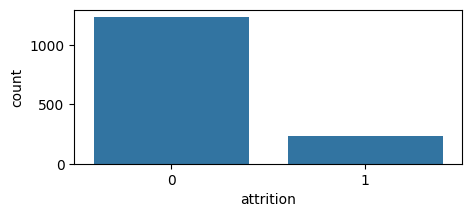

In [ ]:
#Check if data is balanced or not
plt.figure(figsize=(5,2))
sns.countplot(data,x='attrition')

#The target column is not balanced so we go through **SMOTE** method to balce data

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote=SMOTE(random_state=42)
x_sampled,y_sampled=smote.fit_resample(x_train,y_train)

In [ ]:
Counter(y_train)

Counter({0: 978, 1: 198})

In [ ]:
Counter(y_sampled)

Counter({0: 978, 1: 978})

#Scaling the data because some hidden columns are not scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_sampled = scaler.fit_transform(x_sampled)
x_test = scaler.transform(x_test)

#**Built Logistic Classifier Model**

In [ ]:
#logistic model
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

#**Evaluate the Model**

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[237,  18],
       [ 20,  19]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.48717948717948717

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8707482993197279

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.5135135135135135

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.5

In [ ]:
y_prob=model.predict_proba(x_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)


np.float64(0.7814982403217697)

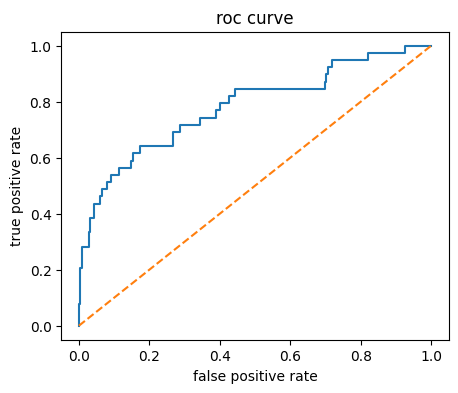

In [ ]:
#roc_curve
fpr,tpr,threshhold=roc_curve(y_test,y_prob)
plt.figure(figsize=(5,4))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('roc curve')
plt.show()

#**KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

#**Evaluate Model**

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[231,  24],
       [ 27,  12]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.3076923076923077

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.826530612244898

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.3333333333333333

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.32

In [ ]:
y_prob=model.predict_proba(x_test)[:,1]

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)


np.float64(0.6558069381598793)

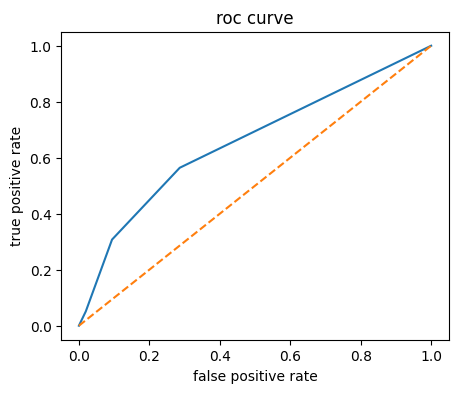

In [ ]:
#roc_curve
fpr,tpr,threshhold=roc_curve(y_test,y_prob)
plt.figure(figsize=(5,4))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('roc curve')
plt.show()

In [ ]:
error_rate=[]
for k in range(2,11):
  model=KNeighborsClassifier(n_neighbors=k)
  model.fit(x_sampled,y_sampled)
  y_pred=model.predict(x_test)
  error_rate.append(np.mean(y_test!=y_pred))
error_rate

[np.float64(0.16326530612244897),
 np.float64(0.17346938775510204),
 np.float64(0.1598639455782313),
 np.float64(0.17346938775510204),
 np.float64(0.1564625850340136),
 np.float64(0.17346938775510204),
 np.float64(0.16326530612244897),
 np.float64(0.19387755102040816),
 np.float64(0.16666666666666666)]

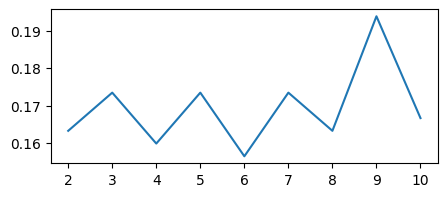

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error_rate)

#**Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion='gini',max_features='sqrt',splitter='best',min_samples_split=5,min_samples_leaf=3)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[216,  39],
       [ 24,  15]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.38461538461538464

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.7857142857142857

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.2777777777777778

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.3225806451612903

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**cross validation**

#K Fold

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
model=DecisionTreeClassifier(criterion='gini',max_features='sqrt',splitter='best',min_samples_split=5,min_samples_leaf=3)
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,x_sampled,y_sampled,cv=kfold)

In [ ]:
scores

array([0.83418367, 0.78516624, 0.82097187, 0.78772379, 0.80818414])

In [ ]:
print(np.mean(scores))

0.8072459418550029


#Stratified KFold

In [ ]:
from sklearn.model_selection import StratifiedKFold
model=DecisionTreeClassifier(criterion='gini',max_features='sqrt',splitter='best',min_samples_split=5,min_samples_leaf=3)
sfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,x_sampled,y_sampled,cv=sfold)

In [ ]:
scores

array([0.83163265, 0.81841432, 0.82097187, 0.82097187, 0.84143223])

In [ ]:
print(np.mean(scores))

0.8266845868782295


#**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=50,max_depth=6,max_features=5,bootstrap=True,min_samples_split=5,min_samples_leaf=3)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[229,  26],
       [ 23,  16]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.41025641025641024

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8333333333333334

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.38095238095238093

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.3950617283950617

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**Hyper Parameter tunnining**

In [ ]:
#Gridsearchcv
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
parameters={'n_estimators': [100, 200], 'max_depth': [5, 10, None],'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]}
grid=GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})

In [ ]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,max_depth=10,max_features=5,bootstrap=True,min_samples_split=2,min_samples_leaf=1)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[241,  14],
       [ 25,  14]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.358974358974359

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8673469387755102

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.5

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.417910447761194

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**Randomized Searchcv**

In [ ]:
#RandomizedSearchcv
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
parameters={'n_estimators': [100, 200], 'max_depth': [5, 10, None],'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]}
random=RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [5, 10, None],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200]})

In [ ]:
print(random.best_params_)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,max_depth=10,max_features=5,bootstrap=True,min_samples_split=2,min_samples_leaf=1)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[242,  13],
       [ 26,  13]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.3333333333333333

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8673469387755102

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.5

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.4

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**Gradient Boosting Classifier**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model=GradientBoostingClassifier()
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[240,  15],
       [ 23,  16]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.41025641025641024

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8707482993197279

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.5161290322580645

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.45714285714285713

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**Hyper Parameter tunning**

In [ ]:
#Greadient Boosting
#Gridsearchcv
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
model=GradientBoostingClassifier()
parameters={"max_depth":[3,4,2],'n_estimators':[100,200,300],'learning_rate':[0.01,0.1,0.2]}
grid=GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 2],
                         'n_estimators': [100, 200, 300]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 300}


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model=GradientBoostingClassifier(learning_rate= 0.2, max_depth=4, n_estimators=300)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[247,   8],
       [ 28,  11]])

In [ ]:
#f1 score
f1_score(y_test,y_pred)


0.3793103448275862

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.5789473684210527

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8775510204081632

In [ ]:
#recall
recall_score(y_test,y_pred)

0.28205128205128205

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**Randomized Searchcv**

In [ ]:
#RandomizedSearchcv
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
model=GradientBoostingClassifier()
parameters={"max_depth":[3,4,2],'n_estimators':[100,200,300],'learning_rate':[0.01,0.1,0.2]}
random=RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_iter=20,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 2],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model=GradientBoostingClassifier(learning_rate= 0.2, max_depth=4, n_estimators=300)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[247,   8],
       [ 28,  11]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.28205128205128205

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.5789473684210527

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8775510204081632

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.3793103448275862

#**XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[242,  13],
       [ 27,  12]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.3076923076923077

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8639455782312925

In [ ]:
#Precition
precision_score(y_test,y_pred)

0.48

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.375

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**GridSearchcv**

In [ ]:
#Gridsearchcv
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
model=XGBClassifier()
parameters={"max_depth":[3,4,2],'n_estimators':[100,200,300],'learning_rate':[0.01,0.1,0.2],
            'reg_alpha':[0.1,0.01,],'reg_lambda':[0.01,0.2,0.3]}
grid=GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 2],
                         'n_estimators': [100, 200, 300],
                         'reg_alpha': [0.1, 0.01],
                         'reg_lambda': [0.01, 0.2, 0.3]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 0.2}


In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier(learning_rate=0.2,max_depth=4,n_estimators=100,reg_alpha=0.01,reg_lambda=0.2)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[242,  13],
       [ 24,  15]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.38461538461538464

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8741496598639455

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.44776119402985076

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**randomizedSearchcv**

In [ ]:
#randomizedsearchcv
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
model=XGBClassifier()
parameters={"max_depth":[3,4,2],'n_estimators':[100,200,300],'learning_rate':[0.01,0.1,0.2],
            'reg_alpha':[0.1,0.01,],'reg_lambda':[0.01,0.2,0.3]}
random=RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 2],
                                        'n_estimators': [100, 200, 300],
                                        'reg_alpha': [0.1, 0.01],
                                        'reg_lambda': [0.01, 0.2, 0.3]})

In [ ]:
print(random.best_params_)

{'reg_lambda': 0.3, 'reg_alpha': 0.01, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}


In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier(learning_rate=0.3,max_depth=4,n_estimators=300,reg_alpha=0.1,reg_lambda=0.3)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[241,  14],
       [ 24,  15]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.38461538461538464

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8707482993197279

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.4411764705882353

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**SupportVectorMachine**

In [ ]:
from sklearn.svm import SVC
model=SVC()
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[250,   5],
       [ 27,  12]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.3076923076923077

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.891156462585034

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.42857142857142855

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**Gridsearchcv**

In [ ]:
#Gridsearchcv
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
model=SVC()
parameters={'C':[1,5,10],'gamma':[0.1,0.01,0.001],'kernel':['poly','linear','sigmoid','rbf']}
grid=GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 5, 10], 'gamma': [0.1, 0.01, 0.001],
                         'kernel': ['poly', 'linear', 'sigmoid', 'rbf']})

In [ ]:
print(grid.best_params_)

{'C': 5, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
from sklearn.svm import SVC
model=SVC(C=5, gamma=0.1, kernel='rbf')
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[255,   0],
       [ 36,   3]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.07692307692307693

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8775510204081632

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.14285714285714285

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**RandomizedSearchcv**

In [ ]:
#randomizedSearchcv
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
model=SVC()
parameters={'C':[1,5,10],'gamma':[0.1,0.01,0.001],'kernel':['poly','linear','sigmoid','rbf']}
random=RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5, estimator=SVC(), n_iter=20,
                   param_distributions={'C': [1, 5, 10],
                                        'gamma': [0.1, 0.01, 0.001],
                                        'kernel': ['poly', 'linear', 'sigmoid',
                                                   'rbf']})

In [ ]:
print(grid.best_params_)

{'C': 5, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
from sklearn.svm import SVC
model=SVC(C=5, gamma=0.1, kernel='rbf')
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
#Confusion matrix
confusion_matrix(y_test,y_pred)

array([[255,   0],
       [ 36,   3]])

In [ ]:
#recall
recall_score(y_test,y_pred)

0.07692307692307693

In [ ]:
#recall
recall_score(y_test,y_pred)

0.07692307692307693

In [ ]:
#Accuracy
accuracy_score(y_test,y_pred)

0.8775510204081632

In [ ]:
#f1 score
f1_score(y_test,y_pred)

0.14285714285714285

In [ ]:
#roc_auc_score
roc_auc_score(y_test,y_prob)

np.float64(0.6558069381598793)

#**Model Selection**

After evaluating multiple classification models, we compared their performance based on accuracy:

Logistic Classifier:  87.0%

KNN Classifier:82%

DecisionTree Classifier:73%

random Forest Classifier:86%

Gredient Boostin Classifier:87.77%

XGBoost Classifier:87.41%

Support Vector Classifier:87.6%

Gradient Boosting Classifier is selected as the best model because it achieved the highest accuracy (87.77%) among all models.

Although SVM (87.6%), XGBoost (87.41%), and Logistic Regression (87%) also performed similarly, Gradient Boosting slightly outperformed them.

#**Overall Conclusion**

Based on the **Exploratory Data Analysis** of the employee attrition dataset, it is evident that employee turnover is influenced by multiple factors rather than a single reason. Variables such as job satisfaction, monthly income, work-life balance, overtime, years at company, and job role play a significant role in determining whether an employee stays or leaves the organization.

The analysis shows that employees with low job satisfaction, lower salary levels, high overtime, and fewer years at the company are more likely to leave. Younger employees and those in certain job roles also tend to have higher attrition rates. On the other hand, employees with better work-life balance, higher income, and longer tenure are more likely to stay with the organization.



#**Key Recomendataion**

**Improve Job Satisfaction:**
  Conduct regular feedback surveys and address employee concerns promptly to increase engagement and morale.

**Promote Work-Life Balance:**
  Reduce excessive overtime and introduce flexible working options to prevent employee burnout.

**Enhance Career Growth Opportunities:**
 Provide training programs, skill development workshops, and clear promotion pathways to motivate employees to stay long-term.

**Strengthen Employee Recognition Programs:**
  Recognize and reward employee achievements to increase motivation and loyalty.

**Focus on High-Risk Groups:**
  Pay special attention to employees with low job satisfaction, short tenure, or high workload, as they are more likely to leave.

